**Problem Statement**

Financial institutions face significant financial losses due to loan defaults. Accurately identifying customers who are likely to default is a major challenge, especially when dealing with large volumes of customer data. Therefore, there is a need for a predictive system that can analyze customer financial and demographic information to estimate the risk of loan default and support better lending decisions.

**Objective**

The objective of this project is to build and evaluate machine learning classification models that predict whether a customer will default on a loan using financial and demographic attributes. The goal is to help financial institutions reduce credit risk by improving loan approval decisions through data-driven prediction.

**Target Variable**

The target variable used in this project is default, defined as:

	•	0 – Customer did not default on the loan
	•	1 – Customer defaulted on the loan

In [ ]:
#import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#load and read the dataset
df= pd.read_csv('/content/Loan_default .csv')

The dataset has been loaded successfully.

In [ ]:
#check the structure of the dataset
df.shape

(255347, 18)

The dataset contains 255347 samples and 18 features.

In [ ]:
#Display the first 5 rows of the dataset
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Displayed the first 5 rows of the dataset.

In [ ]:
#Display the concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

Displayed the concise summary of the  DataFrame.

In [ ]:
#Display the descriptive statistics of the dataset
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Displayed the descriptive statistics of the dataset.

In [ ]:
#Display the names of all the features present in the dataset
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

Displayed the names of all the features present in the dataset

In [ ]:
#Check for the missing values present in the dataset
df.isnull().sum().sum()

np.int64(0)

No missing values found in the dataset.

In [ ]:
#Check for the duplicate values present in the dataset
df.duplicated().sum()

np.int64(0)

No duplicate values are present in the dataset.

In [ ]:
#Drop 'LoanID' column
df=df.drop('LoanID',axis=1)

The column 'LoanID' has been dropped successfully.

In [ ]:
df['LoanTerm']=df['LoanTerm']/12 #Divide the loan term by 12 to convert it into years and make it simpler
df.head(10) #Display the first 10 rows to verify the changes

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,3.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,5.0,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,2.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,2.0,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,4.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,25,90298,90448,720,18,2,22.72,2.0,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,38,111188,177025,429,80,1,19.11,1.0,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,56,126802,155511,531,67,4,8.15,5.0,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,36,42053,92357,827,83,1,23.94,4.0,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,40,132784,228510,480,114,4,9.09,4.0,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


Converted the 'LoanTerm' column to years.

Displayed the first 10 rows to verify the changes.

In [ ]:
#Change the names of few columns to improve readability
df= df.rename(columns={'LoanAmount':'Loan_Amount','CreditScore':'Credit_Score','MonthsEmployed':'Num_of_Months_Employed'})
df= df.rename(columns={'NumCreditLines':'Num_of_Credit_Lines','InterestRate':'Interest_Rate','LoanTerm':'Loan_Term','DTIRatio':'DTI_Ratio','EmploymentType':'Employment_Type','MaritalStatus':'Marital_Status'})
df= df.rename(columns={'HasMortgage':'Mortgage','HasDependents':'Dependents','LoanPurpose':'Loan_Purpose','HasCoSigner':'Co_Signer'})
df.columns

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score',
       'Num_of_Months_Employed', 'Num_of_Credit_Lines', 'Interest_Rate',
       'Loan_Term', 'DTI_Ratio', 'Education', 'Employment_Type',
       'Marital_Status', 'Mortgage', 'Dependents', 'Loan_Purpose', 'Co_Signer',
       'Default'],
      dtype='object')

Column names have been changed successfully.

In [ ]:
#Convert some columns to appropriate datatypes
df[['Education','Employment_Type','Marital_Status','Mortgage','Dependents','Loan_Purpose','Co_Signer','Default']]=df[['Education','Employment_Type','Marital_Status','Mortgage','Dependents','Loan_Purpose','Co_Signer','Default']].astype('category')
df['Loan_Term']=df['Loan_Term'].astype('int64')

Converted some columns to appropriate data types.

In [ ]:
#Display the first 5 rows after changes
df.head()

,Age,Income,Loan_Amount,Credit_Score,Num_of_Months_Employed,Num_of_Credit_Lines,Interest_Rate,Loan_Term,DTI_Ratio,Education,Employment_Type,Marital_Status,Mortgage,Dependents,Loan_Purpose,Co_Signer,Default
0,56,85994,50587,520,80,4,15.23,3,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,5,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,2,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,2,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,4,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Displayed the first 5 rows to verify the changes.

In [ ]:
#Display the concise summary of the DataFrame after changes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   Age                     255347 non-null  int64   
 1   Income                  255347 non-null  int64   
 2   Loan_Amount             255347 non-null  int64   
 3   Credit_Score            255347 non-null  int64   
 4   Num_of_Months_Employed  255347 non-null  int64   
 5   Num_of_Credit_Lines     255347 non-null  int64   
 6   Interest_Rate           255347 non-null  float64 
 7   Loan_Term               255347 non-null  int64   
 8   DTI_Ratio               255347 non-null  float64 
 9   Education               255347 non-null  category
 10  Employment_Type         255347 non-null  category
 11  Marital_Status          255347 non-null  category
 12  Mortgage                255347 non-null  category
 13  Dependents              255347 non-null  category
 14  Loan

Successfully displayed a concise summary of the DataFrame to confirm the changes.

## **Display appropriate visualizations for the dataset.**

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64


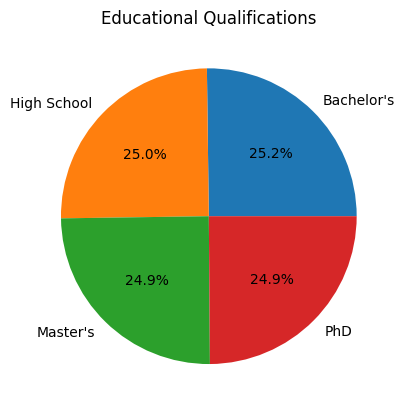

In [ ]:
count= df['Education'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Educational Qualifications')
plt.show()

**Interpretation — Educational Qualifications Pie Chart**

The pie chart shows that the dataset is almost evenly distributed across all education levels:

	•	Bachelor’s degree holders form the largest group, but only slightly, at 25.2%.
	•	High School graduates account for 25.0%.
	•	Master’s degree holders make up 24.9%.
	•	PhD holders also represent 24.9%.

**Key Insigh**t

The proportions are nearly equal, meaning no single education level dominates the dataset. This indicates a balanced representation of different educational backgrounds, which is good for building unbiased machine learning models since the model will not favor one education category due to imbalance.


Employment_Type
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64


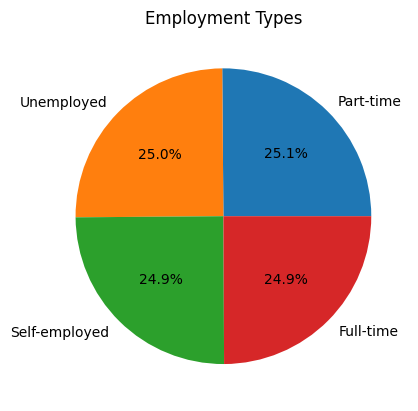

In [ ]:
count= df['Employment_Type'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Employment Types')
plt.show()

**Interpretation — Employment Types Pie Chart**

The pie chart shows that employment categories in the dataset are almost equally distributed:

	•	Part-time employees form the largest group with 25.1% of the total.
	•	Unemployed individuals account for 25.0%.
	•	Self-employed individuals represent 24.9%.
	•	Full-time employees also make up 24.9%.

**Key Insight**

The distribution across employment types is highly balanced, indicating that the dataset includes nearly equal representation of all employment categories. This balance helps ensure that predictive models trained on the data are not biased toward any specific employment type.

Marital_Status
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64


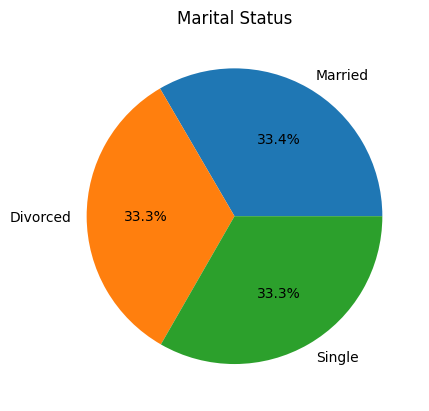

In [ ]:
count= df['Marital_Status'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Marital Status')
plt.show()

**Interpretation — Marital Status Pie Chart**

The pie chart indicates that marital status categories are almost equally represented in the dataset:

	•	Married individuals constitute 33.4%, forming the slightly largest group.
	•	Divorced individuals account for 33.3%.
	•	Single individuals also represent 33.3%.

**Key Insight**

The dataset shows a highly balanced distribution among marital status categories, meaning no single group dominates the data. This balance is beneficial for machine learning models because it helps reduce bias related to marital status when making predictions.



Mortgage
Yes    127677
No     127670
Name: count, dtype: int64


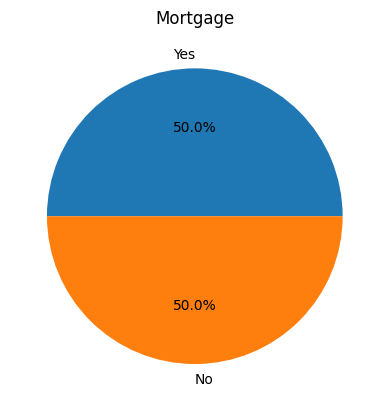

In [ ]:
count=df['Mortgage'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Mortgage')
plt.show()

**Interpretation — Mortgage Status Pie Chart**

The pie chart shows an approximately equal distribution of mortgage status in the dataset:

	•	50% of individuals have a mortgage.
	•	50% of individuals do not have a mortgage.

**Key Insight**

This perfectly balanced distribution indicates that the dataset includes an approximately equal number of individuals with and without mortgages. Such balance is advantageous for predictive modeling, as it prevents bias toward either mortgage group and allows models to learn patterns effectively for both categories.


Dependents
Yes    127742
No     127605
Name: count, dtype: int64


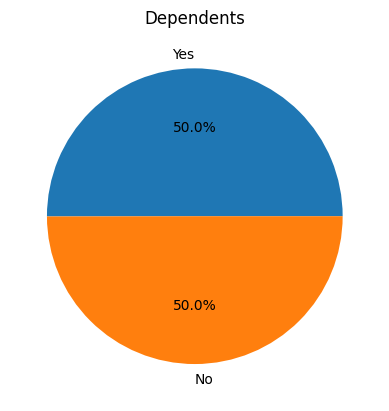

In [ ]:
count=df['Dependents'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Dependents')
plt.show()

**Interpretation — Dependents Pie Chart**

The pie chart shows an approximately equal distribution of individuals with and without dependents:

	•	50% of individuals have dependents.
	•	50% of individuals do not have dependents.

**Key Insight**

This perfectly balanced distribution ensures that both categories are equally represented in the dataset. Such balance is beneficial for machine learning models, as it prevents bias toward either group and helps the model learn patterns effectively for individuals both with and without dependents.


Loan_Purpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64


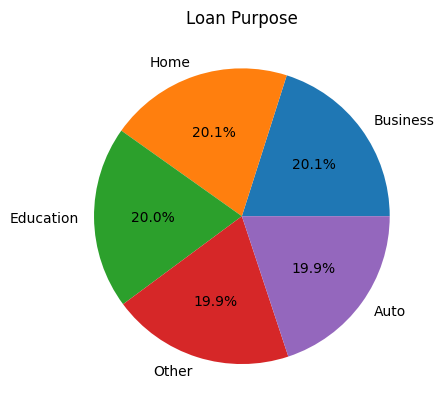

In [ ]:
count=df['Loan_Purpose'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Loan Purpose')
plt.show()

**Interpretation — Loan Purpose Pie Chart**

The pie chart indicates that loan purposes are nearly equally distributed across all categories:

	•	Business loans account for 20.1% of total loans.
	•	Home loans also represent 20.1%.
	•	Education loans make up 20.0%.
	•	Other purposes contribute 19.9%.
	•	Auto loans also account for 19.9%.

**Key Insight**

The dataset shows an almost uniform distribution of loan purposes, meaning no single loan type dominates the data. This balanced representation helps ensure that predictive models learn patterns across different loan purposes without bias toward any specific category.

Co_Signer
Yes    127701
No     127646
Name: count, dtype: int64


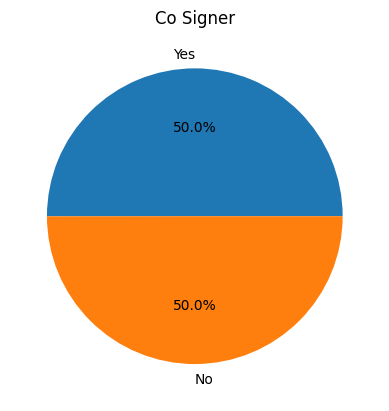

In [ ]:
count=df['Co_Signer'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Co Signer')
plt.show()

**Interpretation — Co-signer Status Pie Chart**

The pie chart shows an equal distribution of loans with and without a co-signer:

	•	50% of applicants have a co-signer.
	•	50% of applicants do not have a co-signer.

**Key Insight**

This perfectly balanced distribution ensures equal representation of both categories in the dataset. Such balance helps machine learning models learn patterns fairly for applicants with and without co-signers, reducing the risk of bias toward one group.

Default
0    225694
1     29653
Name: count, dtype: int64


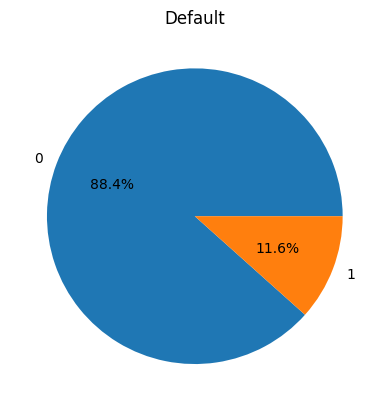

In [ ]:
count=df['Default'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Default')
plt.show()

**Interpretation — Loan Default Distribution**

The pie chart shows the distribution of the target variable (loan default status) in the dataset:

	•	88.4% of borrowers did not default on their loans (class 0).
	•	11.6% of borrowers defaulted on their loans (class 1).

**Key Insight**

The dataset is significantly imbalanced, with non-default cases greatly outnumbering default cases. This imbalance can cause machine learning models to favor predicting non-default cases, potentially reducing performance in identifying actual defaults.

**Modeling Implication**

To address this imbalance, techniques such as class weighting, or evaluation using precision, recall, and F1-score should be considered instead of relying solely on accuracy.

Loan_Term
4    51166
5    51154
3    51061
2    51009
1    50957
Name: count, dtype: int64


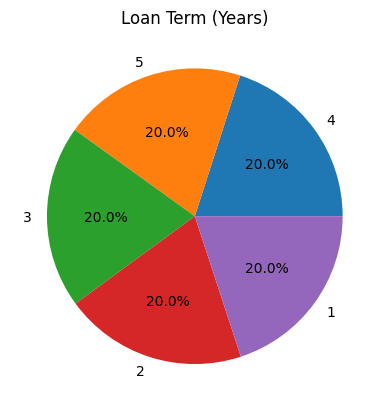

In [ ]:
count=df['Loan_Term'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Loan Term (Years)')
plt.show()

**Interpretation — Loan Term Distribution**

The pie chart shows that loan terms are evenly distributed across all available durations:

	•	Each loan term category (1, 2, 3, 4, and 5 years) represents approximately 20% of the dataset.

**Key Insight**

The dataset contains an approximate equal proportion of loans across different term lengths, indicating that no single loan duration dominates the dataset. This balanced distribution allows machine learning models to learn patterns across all loan durations without bias toward a specific loan term.

**Modeling Implication**

Since loan terms are evenly represented, no special handling for imbalance is required for this feature, making it suitable for modeling without additional adjustments.

Num_of_Credit_Lines
2    64130
3    63834
4    63829
1    63554
Name: count, dtype: int64


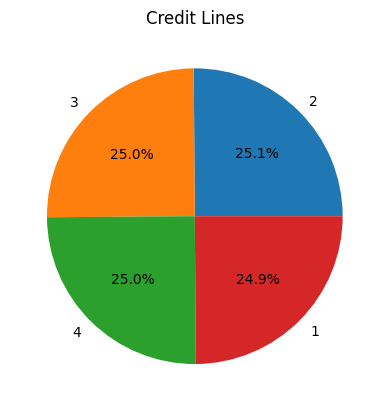

In [ ]:
count=df['Num_of_Credit_Lines'].value_counts()
print(count)
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.title('Credit Lines')
plt.show()

**Interpretation — Credit Lines Distribution**

The pie chart shows that the number of credit lines among borrowers is almost evenly distributed:

	•	Borrowers with 2 credit lines form the largest group at 25.1%.
	•	Those with 3 credit lines account for 25.0%.
	•	Borrowers with 4 credit lines also represent 25.0%.
	•	Individuals with 1 credit line make up 24.9%.

**Key Insight**

The distribution is highly balanced, indicating that borrowers in the dataset are nearly equally spread across different credit line counts. This ensures that predictive models can learn patterns effectively across all credit line categories without bias toward a particular group.

**Modeling Implication**

Since all categories are well represented, this feature does not require imbalance handling and can be used directly in model training.


**Interpretation — Correlation Heatmap of Numerical Features**

The correlation heatmap shows relationships among numerical variables and their association with the loan default outcome.

**Key Observations**

	•	Most features show very low correlation with each other, indicating minimal multicollinearity in the dataset.
	•	Age (-0.17) has the strongest negative correlation with default, suggesting older borrowers are slightly less likely to default.
	•	Interest rate (0.13) shows a positive correlation with default, meaning higher interest rates are associated with higher default risk.
	•	Income (-0.10) and months employed (-0.10) also show weak negative relationships with default, implying financially stable individuals are less likely to default.
	•	Loan amount (0.09) has a small positive correlation with default.
	•	Features like loan term and DTI ratio show almost no direct correlation with default.

**Key Insight**

No single feature strongly explains loan default, indicating that loan default prediction depends on the combined effect of multiple variables rather than one dominant factor.

**Modeling Implication**

The low inter-feature correlations are beneficial because they reduce multicollinearity issues, allowing machine learning models to learn patterns effectively from multiple independent predictors.



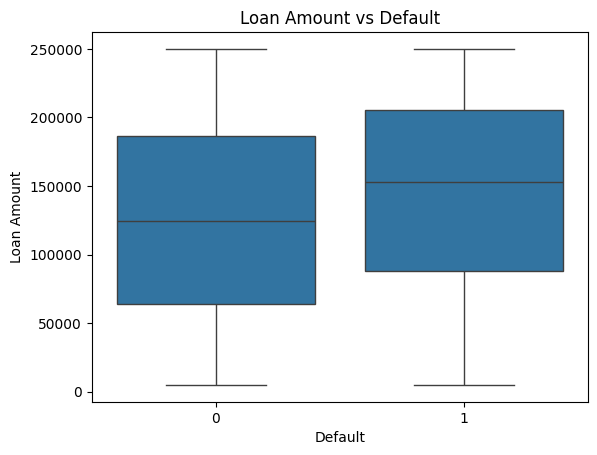

In [ ]:
plt.xlabel('Default')
plt.ylabel('Loan Amount')
plt.title('Loan Amount vs Default')
sns.boxplot(x='Default', y='Loan_Amount', data=df)
plt.show()

The boxplot compares loan amounts for two groups:

	•	0 → Non-default customers
	•	1 → Default customers

**Key Interpretation:**

	•	Higher median for defaulters: The median loan amount for customers who defaulted (1) is higher than for those who did not (0). This suggests that people with larger loans are more likely to default.

	•	Distribution spread: The interquartile range (IQR) for defaulters is slightly wider, indicating more variability in loan amounts among defaulting customers.

	•	Overlap exists: There is a significant overlap between the two groups, meaning loan amount alone is not a strong standalone predictor of default.

	•	Upper range similarity: Both groups reach similar maximum loan values (~250,000), indicating that high loan amounts exist in both categories.

	•	Lower quartile difference: Non-defaulters tend to have lower loan amounts in the lower quartile compared to defaulters.

**Conclusion:**

While higher loan amounts are somewhat associated with default, the overlap shows that loan amount alone is insufficient to predict default, and should be combined with other features (like income, credit history, etc.) for better prediction.

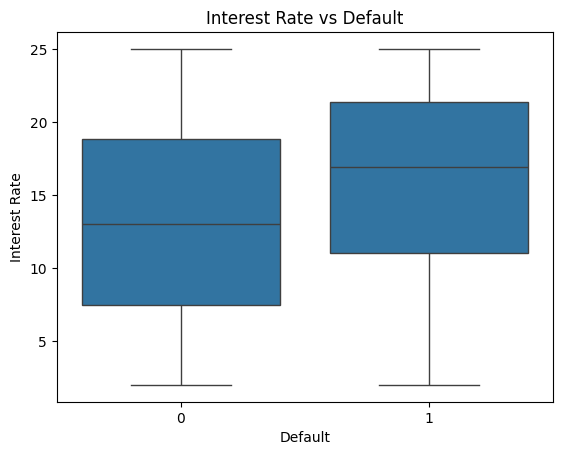

In [ ]:
plt.xlabel('Default')
plt.ylabel('Interest Rate')
plt.title('Interest Rate vs Default')
sns.boxplot(x='Default', y='Interest_Rate', data=df)
plt.show()

**Interpretation of Interest Rate vs Default:**

	•	Higher median for defaulters: The median interest rate for defaulting customers (1) is clearly higher than for non-defaulters (0). This indicates that loans with higher interest rates are more likely to result in default.

	•	Shift in distribution: The entire box (IQR) for defaulters is shifted upward compared to non-defaulters, showing that most default cases occur at relatively higher interest rates.

	•	Greater risk at higher rates: As interest rates increase, the financial burden on borrowers rises, which can increase the probability of default.

	•	Overlap still present: Although defaulters tend to have higher interest rates, there is still overlap between the two groups. This means interest rate alone cannot perfectly distinguish defaulters from non-defaulters.

	•	Similar range: Both groups span a similar overall range (roughly 2% to 25%), indicating that defaults occur across all interest levels, but are more concentrated at higher values.

**Conclusion:**

Interest rate is a stronger indicator of default compared to loan amount, as there is a clearer upward shift for defaulters. However, it still needs to be combined with other variables for accurate prediction.

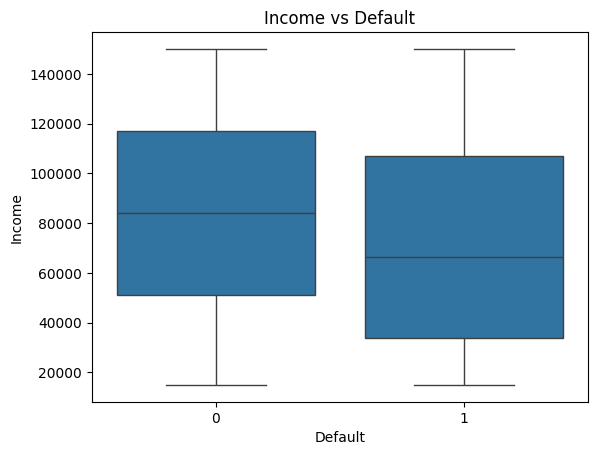

In [ ]:
plt.xlabel('Default')
plt.ylabel('Income')
plt.title('Income vs Default')
sns.boxplot(x='Default', y='Income', data=df)
plt.show()

**Interpretation of Income vs Default:**

	•	Lower median for defaulters: The median income of defaulting customers (1) is noticeably lower than that of non-defaulters (0). This suggests that individuals with lower income are more likely to default.

	•	Downward shift in distribution: The IQR (box) for defaulters is shifted downward compared to non-defaulters, indicating that a large proportion of defaulters fall in the lower income range.

	•	Income as a protective factor: Higher income appears to reduce the risk of default, likely because individuals with greater financial stability can manage loan repayments more effectively.

	•	Overlap between groups: There is still considerable overlap in income distributions, meaning some high-income individuals also default and some low-income individuals do not.

	•	Similar overall range: Both groups span a similar income range (~15,000 to 150,000), showing that default is not limited to only low-income individuals, though it is more concentrated there.

**Conclusion:**

Income is an important inverse indicator of default—as income decreases, the likelihood of default increases. However, like other features, it should be combined with additional variables for accurate prediction.

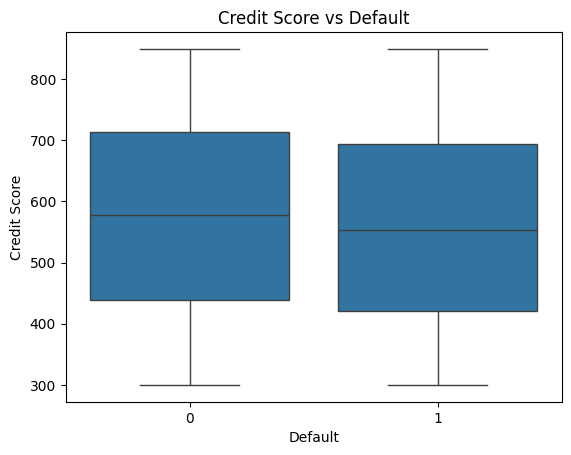

In [ ]:
plt.xlabel('Default')
plt.ylabel('Credit Score')
plt.title('Credit Score vs Default')
sns.boxplot(x='Default', y='Credit_Score', data=df)
plt.show()

**Interpretation of Credit Score vs Default:**

	•	Slightly lower median for defaulters: The median credit score of defaulting customers (1) is a bit lower than that of non-defaulters (0). This suggests that lower credit scores are associated with a higher likelihood of default.

	•	Less pronounced difference: Compared to income or interest rate, the separation between the two groups is not very strong. The medians are close, indicating weaker discriminatory power.

	•	Significant overlap: There is a large overlap in the distributions of credit scores for defaulters and non-defaulters. This means many individuals with good credit scores still default, and vice versa.

	•	Similar spread: Both groups have a similar range (around 300 to 850) and comparable IQRs, indicating similar variability in credit scores.

	•	Slight downward shift for defaulters: Although subtle, the distribution for defaulters is slightly shifted toward lower values.

**Conclusion:**

Credit score is a useful but relatively weaker predictor compared to features like interest rate or income. While lower scores are associated with higher default risk, the strong overlap suggests it should be combined with other features for better predictive performance.

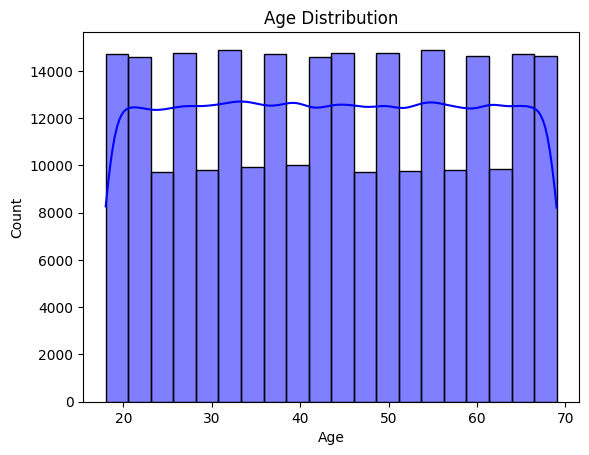

In [ ]:
x=df['Age']
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='blue')
plt.show()

**Interpretation — Age Distribution**

The histogram shows that the distribution of age among individuals is nearly uniform across the range of approximately 18 to 70 years.

	•	The counts for different age groups are fairly consistent, indicating no dominant age category.
	•	The KDE (smooth blue curve) appears relatively flat, suggesting the absence of significant skewness in the data.
	•	There are only minor fluctuations in frequency across bins, which are likely due to randomness rather than any meaningful pattern.

**Key Insight**

The age distribution is well-balanced, indicating that individuals of all age groups are almost equally represented in the dataset. This ensures that there is no age-related bias in the data.

**Modeling Implication**

Since the age feature is evenly distributed, it does not require any special preprocessing for imbalance and can be effectively used in model training without introducing bias toward a particular age group.

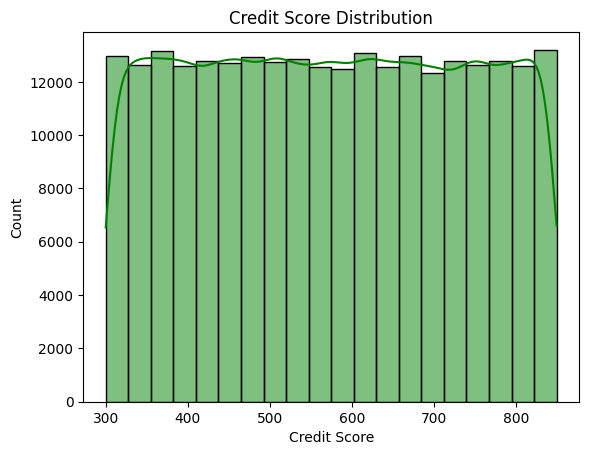

In [ ]:
x=df['Credit_Score']
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.title('Credit Score Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='green')
plt.show()

**Interpretation — Credit Score Distribution**

The histogram shows that credit scores are distributed almost uniformly across the range of approximately 300 to 850.

	•	The frequency of observations across different credit score intervals is fairly consistent, with no single range dominating the distribution.
	•	The KDE (smooth green curve) is relatively flat, indicating the absence of strong skewness in the data.
	•	Minor variations in bar heights are present but do not suggest any significant clustering or trend.

**Key Insight**

The distribution of credit scores is well-balanced, meaning individuals with low, medium, and high credit scores are nearly equally represented in the dataset. This ensures comprehensive coverage across all credit categories.

**Modeling Implication**

Since the credit score feature is evenly distributed, it does not require special handling for imbalance and can be directly used in model training. This balanced representation helps the model learn patterns effectively across all credit score ranges without bias.

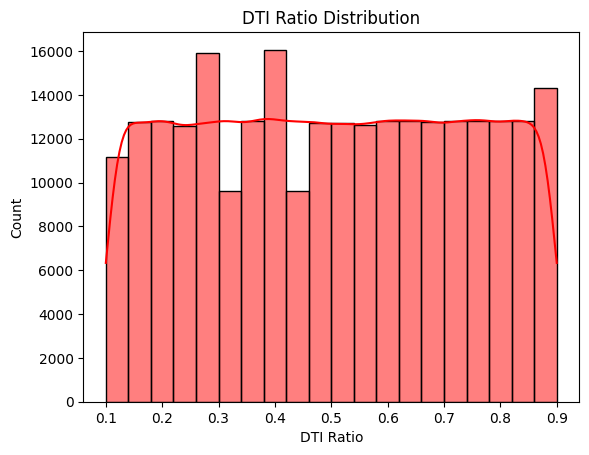

In [ ]:
x=df['DTI_Ratio']
plt.xlabel('DTI Ratio')
plt.ylabel('Count')
plt.title('DTI Ratio Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='red')
plt.show()

**Interpretation — DTI Ratio Distribution**

The histogram shows that the Debt-to-Income (DTI) ratio is distributed almost uniformly across the range of approximately 0.1 to 0.9.

	•	The counts across different DTI intervals are fairly consistent, indicating no strong concentration in any specific range.
	•	The KDE (smooth red curve) appears relatively flat, suggesting there is no significant skewness in the distribution.
	•	Slight fluctuations are visible, but they are minimal and likely due to random variation rather than a meaningful pattern.

**Key Insight**

The DTI ratio is well-balanced across low, medium, and high values, meaning borrowers with varying financial burdens are equally represented in the dataset. This provides a comprehensive view of different financial risk levels.

**Modeling Implication**

Since the DTI ratio is evenly distributed, no special handling for imbalance is required. The feature can be directly used in model training, allowing the model to learn patterns effectively across all levels of financial risk without bias.

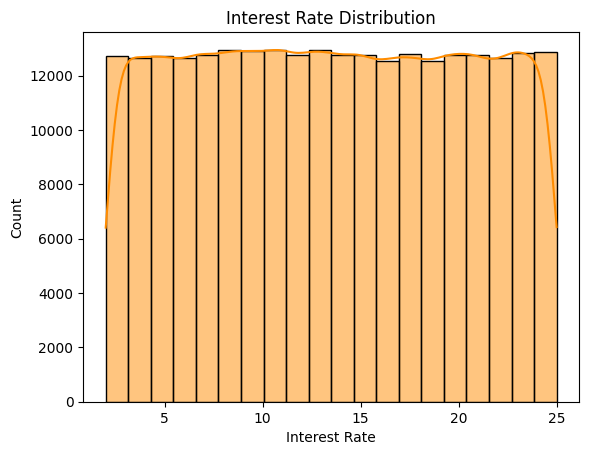

In [ ]:
x=df['Interest_Rate']
plt.xlabel('Interest Rate')
plt.ylabel('Count')
plt.title('Interest Rate Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='darkorange')
plt.show()


**Interpretation — Interest Rate Distribution**

The histogram shows that interest rates are distributed almost uniformly across the range of approximately 2% to 25%.

	•	The counts across different interest rate intervals are fairly consistent, indicating no dominant range.
	•	The KDE (smooth orange curve) appears relatively flat, suggesting there is no significant skewness in the distribution.
	•	Minor fluctuations in the bars are present but do not indicate any strong clustering or pattern.

**Key Insight**

The interest rate distribution is well-balanced, meaning loans with low, moderate, and high interest rates are nearly equally represented in the dataset. This ensures comprehensive coverage of different lending conditions.

**Modeling Implication**

Since the interest rate feature is evenly distributed, it does not require special imbalance handling and can be directly used in model training. This balanced spread allows the model to learn effectively across all interest rate levels without bias.

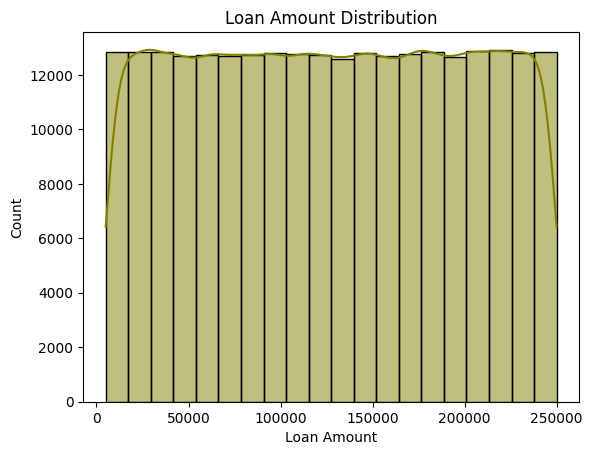

In [ ]:
x=df['Loan_Amount']
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.title('Loan Amount Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='olive')
plt.show()

**Interpretation — Loan Amount Distribution**

The histogram shows that loan amounts are distributed almost uniformly across the range of approximately 5,000 to 250,000.
	•	The counts across different loan amount intervals are fairly consistent, indicating no particular range dominates the dataset.
	•	The KDE (smooth olive curve) appears relatively flat, suggesting the absence of significant skewness.
	•	Minor variations are observed in some bins, but these are small and likely due to random fluctuations rather than any meaningful pattern.

**Key Insight**

The loan amount distribution is well-balanced, meaning small, medium, and large loan amounts are nearly equally represented in the dataset. This provides a comprehensive view across different borrowing levels.

**Modeling Implication**

Since the loan amount feature is evenly distributed, it does not require special handling for imbalance and can be directly used in model training. This balanced representation helps the model learn patterns effectively across all loan amount ranges without bias.

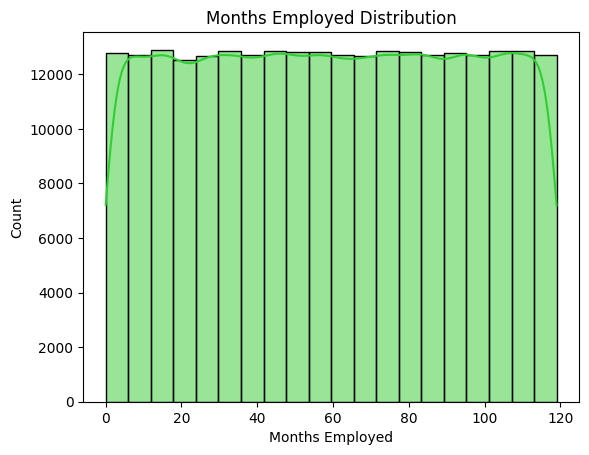

In [ ]:
x=df['Num_of_Months_Employed']
plt.xlabel('Months Employed')
plt.ylabel('Count')
plt.title('Months Employed Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='limegreen')
plt.show()

**Interpretation — Months Employed Distribution**

The histogram shows that months employed are distributed almost uniformly across the range of approximately 0 to 120 months.
	•	The counts across different employment duration intervals are fairly consistent, indicating no specific tenure range dominates the dataset.
	•	The KDE (smooth green curve) appears relatively flat, suggesting there is no significant skewness in the distribution.
	•	Minor fluctuations exist but are minimal and likely due to random variation rather than any meaningful trend.

**Key Insight**

The distribution of months employed is well-balanced, meaning individuals with low, moderate, and high employment durations are nearly equally represented. This ensures a diverse representation of work experience levels in the dataset.

**Modeling Implication**

Since the months employed feature is evenly distributed, it does not require special imbalance handling and can be directly used in model training. This balanced spread allows the model to learn patterns effectively across all employment durations without bias.

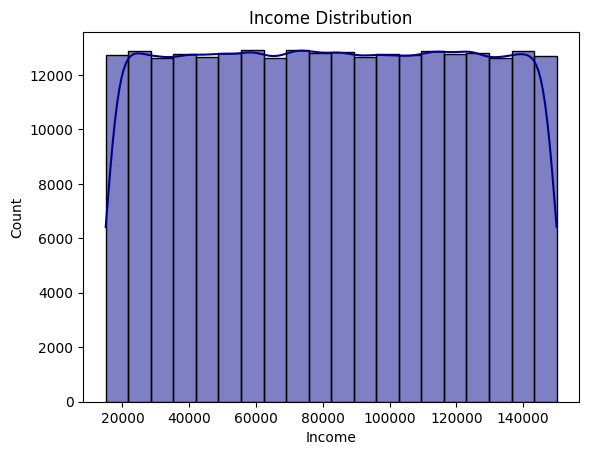

In [ ]:
x=df['Income']
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Income Distribution')
sns.histplot(x,bins=20,kde=True,edgecolor='black',color='darkblue')
plt.show()

**Interpretation — Income Distribution**

The histogram shows that income is distributed almost uniformly across the range of approximately 20,000 to 150,000.
	•	The counts across different income intervals are fairly consistent, indicating no single income group dominates the dataset.
	•	The KDE (smooth blue curve) appears relatively flat, suggesting there is no significant skewness in the distribution.
	•	Minor fluctuations are present but are small and likely due to random variation rather than any meaningful pattern.

**Key Insight**

The income distribution is well-balanced, meaning individuals across low, medium, and high income levels are nearly equally represented in the dataset. This ensures a comprehensive coverage of different earning groups.

**Modeling Implication**

Since the income feature is evenly distributed, it does not require special handling for imbalance and can be directly used in model training. This balanced representation allows the model to learn effectively across all income levels without bias.

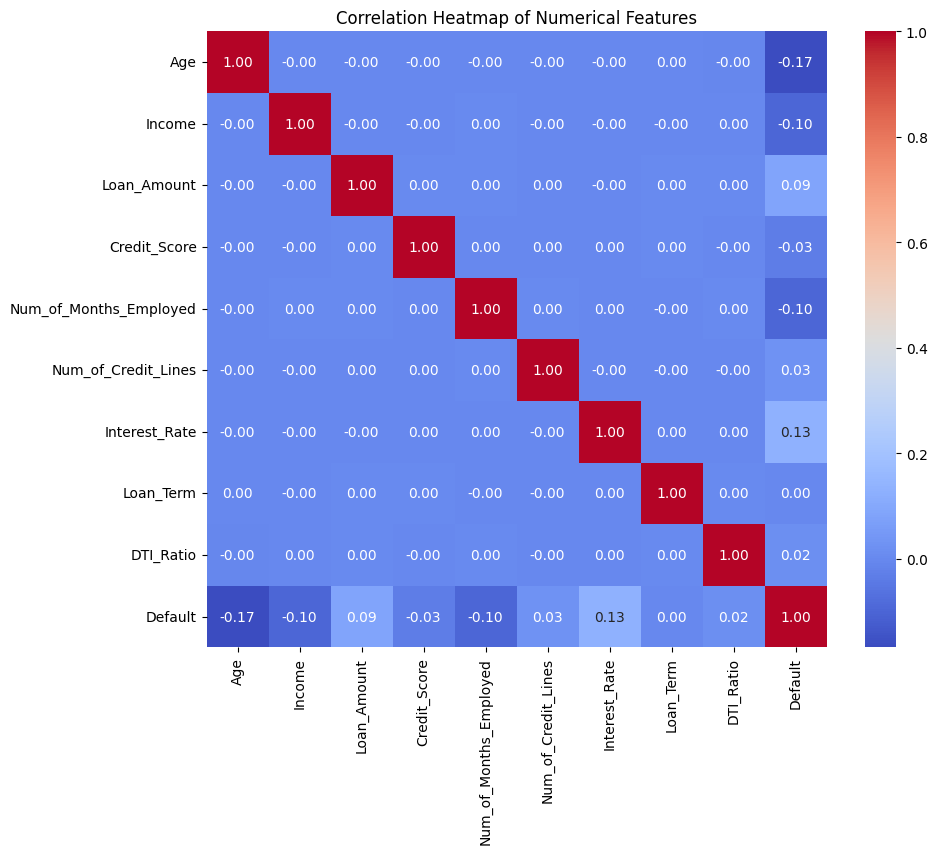

In [ ]:
num_features=['Age', 'Income', 'Loan_Amount', 'Credit_Score',
       'Num_of_Months_Employed', 'Num_of_Credit_Lines', 'Interest_Rate',
       'Loan_Term', 'DTI_Ratio', 'Default']

correlation_matrix= df[num_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Interpretation — Correlation Heatmap of Numerical Features**

The correlation heatmap shows relationships among numerical variables and their association with the loan default outcome.

**Key Observations**

•   Most features show very low correlation with each other, indicating minimal multicollinearity in the dataset.

•   Age (-0.17) has the strongest negative correlation with default, suggesting older borrowers are slightly less likely to default.

•   Interest rate (0.13) shows a positive correlation with default, meaning higher interest rates are associated with higher default risk.

•   Income (-0.10) and months employed (-0.10) also show weak negative relationships with default, implying financially stable individuals are less likely to default.

•   Loan amount (0.09) has a small positive correlation with default.

•   Features like loan term and DTI ratio show almost no direct correlation with default.
Key Insight

No single feature strongly explains loan default, indicating that loan default prediction depends on the combined effect of multiple variables rather than one dominant factor.

**Modeling Implication**

The low inter-feature correlations are beneficial because they reduce multicollinearity issues, allowing machine learning models to learn patterns effectively from multiple independent predictors.

#Find outliers

In [ ]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return outliers, lower_bound, upper_bound

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    outliers, lb, ub = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Income: 0 outliers
Loan_Amount: 0 outliers
Credit_Score: 0 outliers
Num_of_Months_Employed: 0 outliers
Num_of_Credit_Lines: 0 outliers
Interest_Rate: 0 outliers
Loan_Term: 0 outliers
DTI_Ratio: 0 outliers


No Outliers found in the dataset.

In [ ]:
#Label encoding for binary category features

binary_cols=['Mortgage','Dependents','Co_Signer']

for cols in binary_cols:
  df[cols]=df[cols].map({'Yes':1,'No':0})

Binary category features have been encoded with binary labels successfully.

In [ ]:
#Map the multi-category features with numbers

df['Education']=df['Education'].map({'High School':0,"Bachelor's":1,"Master's":2,'PhD':3})
df['Employment_Type']=df['Employment_Type'].map({'Unemployed':0,'Self-employed':1,'Part-time':2,'Full-time':3})
df['Marital_Status']=df['Marital_Status'].map({'Single':0,'Married':1,'Divorced':2})
df['Loan_Purpose']=df['Loan_Purpose'].map({'Auto':0, 'Business':1, 'Education':2, 'Home':3, 'Other':4})

Successfully mapped multi-category features with appropriate numbers.

In [ ]:
#Define the features and the target variable

features=[
    'Credit_Score','Num_of_Months_Employed','Num_of_Credit_Lines','Interest_Rate','Loan_Amount','DTI_Ratio','Loan_Term','Marital_Status','Education','Employment_Type','Mortgage','Dependents','Loan_Purpose','Co_Signer','Age','Income'
]
target='Default'

x=df[features]
y=df[target]

Defined the features and the target variable successfully.

In [ ]:
df.head(10) #Display the first 10 rows to confirm the changes

,Age,Income,Loan_Amount,Credit_Score,Num_of_Months_Employed,Num_of_Credit_Lines,Interest_Rate,Loan_Term,DTI_Ratio,Education,Employment_Type,Marital_Status,Mortgage,Dependents,Loan_Purpose,Co_Signer,Default
0,56,85994,50587,520,80,4,15.23,3,0.44,1,3,2,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,5,0.68,2,3,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,2,0.31,2,0,2,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,2,0.23,0,3,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,4,0.73,1,0,2,0,1,0,0,0
5,25,90298,90448,720,18,2,22.72,2,0.10,0,0,0,1,0,1,1,1
6,38,111188,177025,429,80,1,19.11,1,0.16,1,0,0,1,0,3,1,0
7,56,126802,155511,531,67,4,8.15,5,0.43,3,3,1,0,0,3,1,0
8,36,42053,92357,827,83,1,23.94,4,0.20,1,1,2,1,0,2,0,1
9,40,132784,228510,480,114,4,9.09,4,0.33,0,1,1,1,0,4,1,0


Displayed the first 10 rows of the dataset to verify the changes.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components = None))
])

x_pca = pca_pipeline.fit_transform(x)

explained_var = pca_pipeline.named_steps['pca'].explained_variance_ratio_
cum_var = np.cumsum(explained_var)
print('Cumulative Explained Variance:', cum_var)

n_comp = np.argmax(cum_var >= 0.95) + 1
print(f'Components for 95% variance: {n_comp}')

pca_pipeline.set_params(pca__n_components = n_comp)
components = pca_pipeline.fit_transform(x)
pca_df = pd.DataFrame(
    components,
    columns = [f'PC{i+1}' for i in range(n_comp)]
)


Cumulative Explained Variance: [0.06331286 0.12644148 0.18943195 0.25237599 0.31519583 0.37794209
 0.44057493 0.50308669 0.56557799 0.62797074 0.69019293 0.75238192
 0.81453589 0.87651044 0.93834628 1.        ]
Components for 95% variance: 16


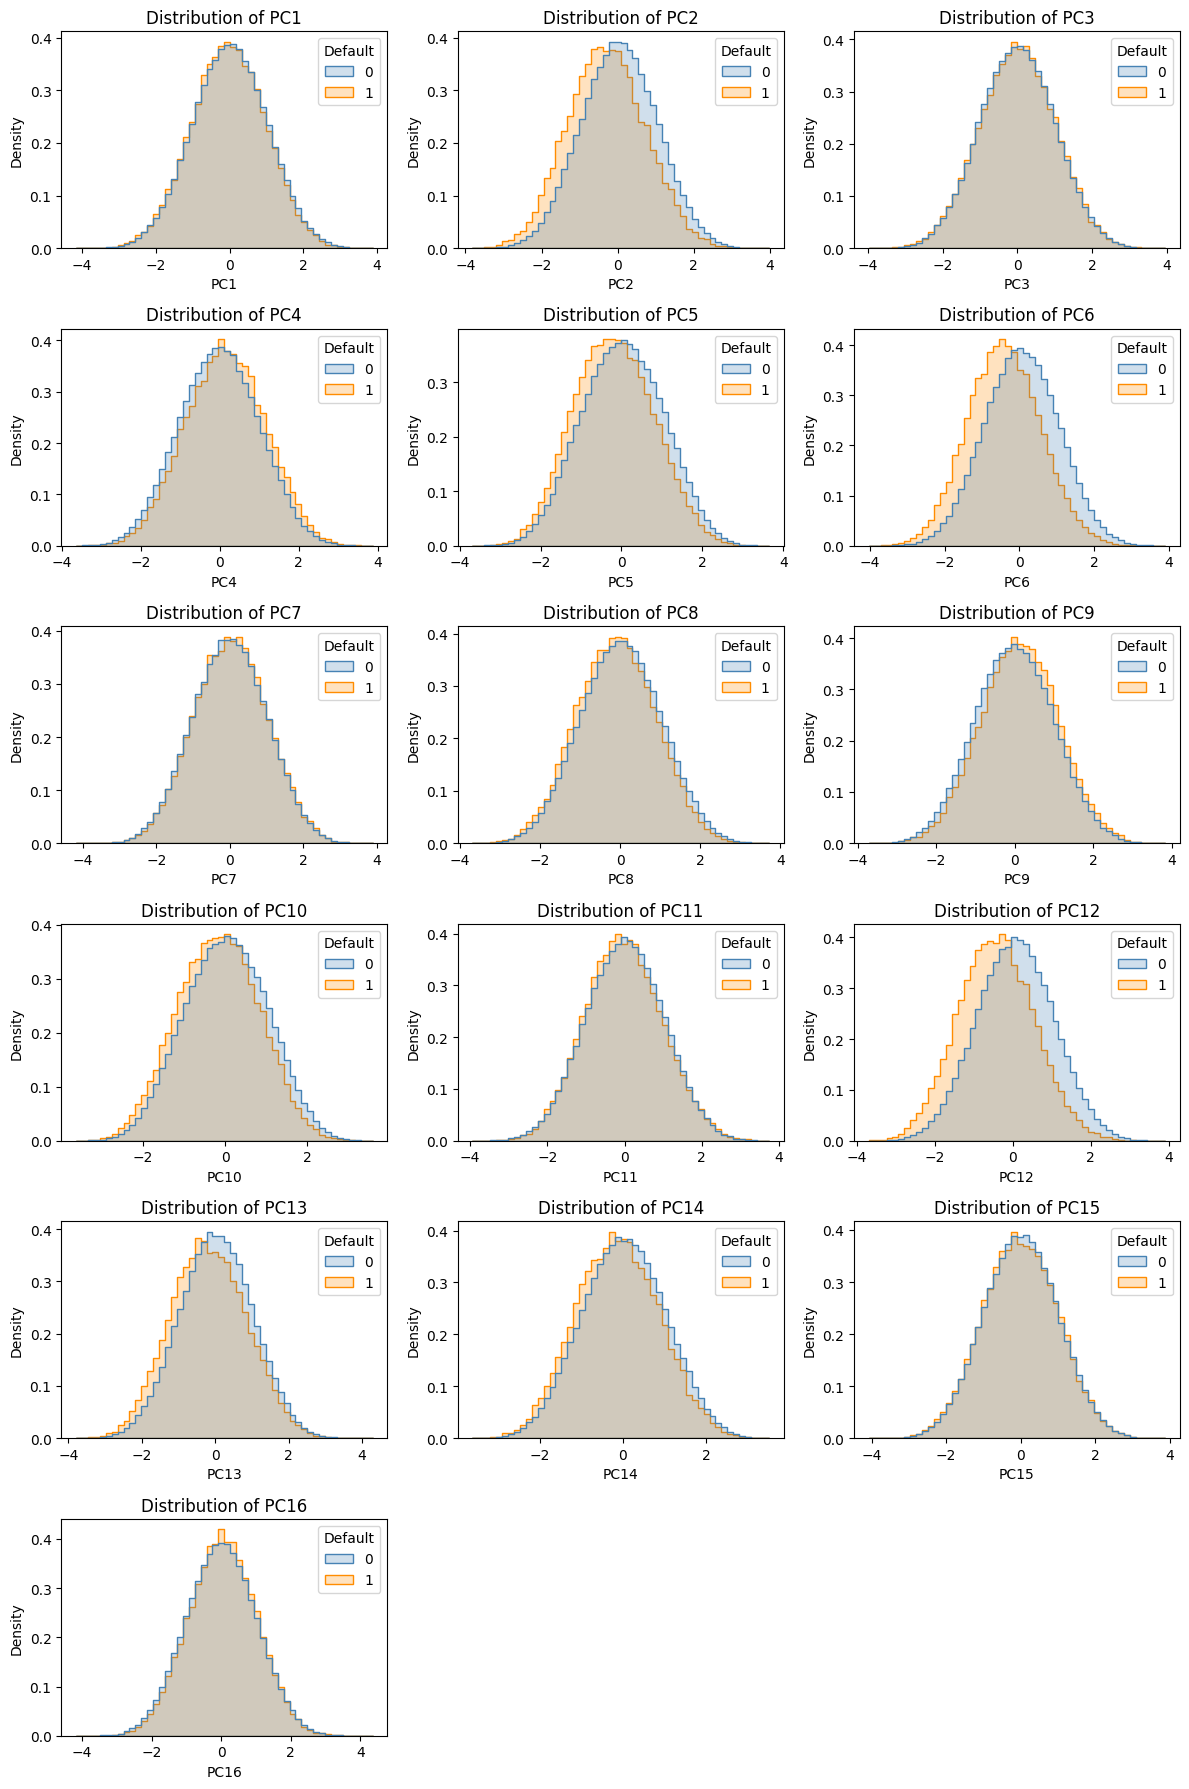

In [ ]:
# Visualize PCs
fig, axes = plt.subplots(6, 3, figsize = (12, 18)) if n_comp >= 6 else plt.subplots(
    1,
    n_comp,
    figsize = (4 * n_comp, 4)
)

for i, ax in enumerate(axes.flat if n_comp > 1 else [axes], start = 1):
    if i > n_comp:
        ax.axis('off')
        continue
    sns.histplot(
        data = pca_df,
        x = f'PC{i}',
        hue = y,
        bins = 50,
        element = 'step',
        stat = 'density',
        common_norm = False,
        palette = {0: 'steelblue', 1: 'darkorange'},
        ax = ax
    )
    ax.set_title(f'Distribution of PC{i}')
    ax.set_xlabel(f'PC{i}')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()


This figure shows the distribution of Principal Components (PC1–PC16) after applying Principal Component Analysis (PCA), comparing two classes

	•	Default = 0 (Non-defaulters – blue)
	•	Default = 1 (Defaulters – orange)

Overall Interpretation

	1.	Normal Distribution Pattern
	•	Most principal components follow a bell-shaped (approximately normal) distribution centered around 0.
	•	This is expected because PCA transforms the original features into standardized orthogonal components.

	2.	Overlap Between Classes
	•	For many components (PC1, PC3, PC4, PC7, PC8, PC11, PC15, PC16), the blue and orange distributions almost completely overlap.
	•	This indicates that these components do not strongly differentiate defaulters from non-defaulters.

	3.	Components Showing Slight Separation
Some PCs show small shifts between the two classes, which may contain useful predictive information:

	•	PC2
	•	PC5
	•	PC6
	•	PC9
	•	PC10
	•	PC12
	•	PC13
	•	PC14

In these components, the orange and blue curves are slightly shifted left or right, indicating different mean values between classes.

	4.	Most Informative Components
	•	PC6, PC10, and PC12 show relatively more noticeable separation, suggesting these components may contribute more to default prediction models.

	5.	Class Imbalance Insight
	•	The curves for Default = 1 appear slightly lower because defaulters are fewer in number, which is common in credit default datasets.

Key Conclusion

	•	Most PCA components have significant overlap, meaning the separation between defaulters and non-defaulters is not strongly visible in individual components.
	•	However, subtle shifts in some PCs indicate that a combination of components can still help machine learning models distinguish between the classes.



In [ ]:
#Split the dataset into training and test sets

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=42)

The dataset has been split into training and test sets.

In [ ]:
#Perform feature scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

The features have been scaled using StandardScaler.

In [ ]:
#Import and fit Logistic Regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(x_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Logistic Regression has been implemented successfully.

<Figure size 1000x500 with 0 Axes>

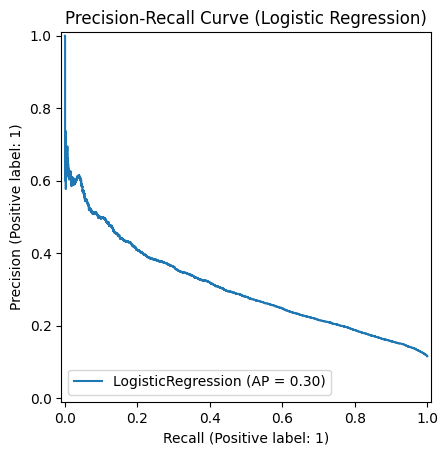

<Figure size 1000x500 with 0 Axes>

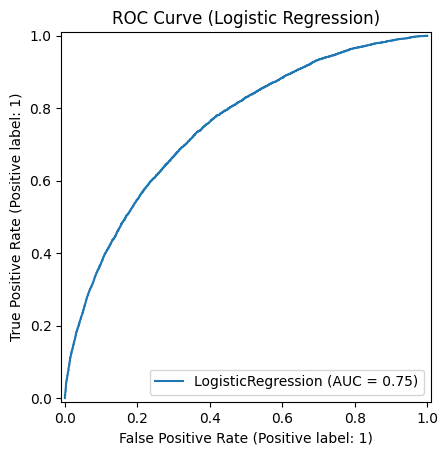

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay # Changed ROCAUCDisplay to RocCurveDisplay
import matplotlib.pyplot as plt

# Create and display Precision-Recall Curve
plt.figure(figsize=(10, 5))
disp_pr = PrecisionRecallDisplay.from_estimator(lr, x_test_scaled, y_test)
disp_pr.ax_.set_title('Precision-Recall Curve (Logistic Regression)')

# Create and display ROC Curve
plt.figure(figsize=(10, 5))
disp_roc = RocCurveDisplay.from_estimator(lr, x_test_scaled, y_test)
disp_roc.ax_.set_title('ROC Curve (Logistic Regression)')

plt.show()

The ROC curve shows that the Logistic Regression model has a moderate ability to distinguish between defaulters and non-defaulters, with an AUC of 0.75, meaning it performs significantly better than random guessing. However, the Precision-Recall curve reveals that the model struggles to accurately identify defaulters, with a low Average Precision of 0.30. As recall increases, precision drops sharply, indicating a high number of false positives. Overall, while the model is reasonably good at ranking predictions, it is less effective in correctly identifying the positive class, suggesting the need for improvement, especially in handling class imbalance.

Evaluation for Logistic Regression:
Accuracy: 0.68
Confusion Matrix:
 [[30433 14737]
 [ 1804  4096]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.67      0.79     45170
           1       0.22      0.69      0.33      5900

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.68      0.73     51070

Roc_Auc_Score:
 0.68


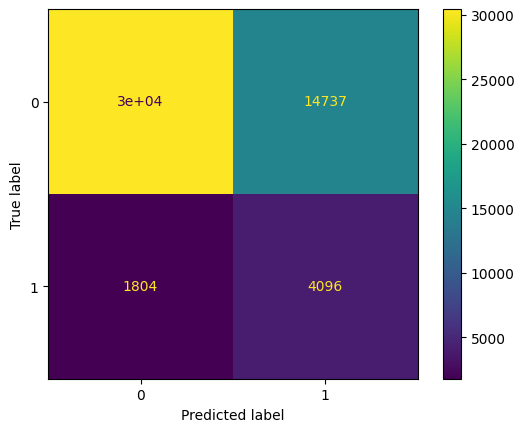

In [ ]:
#Import compute and display the required metrics for test data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate(model, name, X_test_data):
  y_pred_continuous = lr.predict(X_test_data)
  y_pred = (y_pred_continuous >= 0.5).astype(int)

  accuracy = round(accuracy_score(y_test, y_pred),2)
  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)
  roc_auc= round(roc_auc_score(y_test, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.show()
evaluate(lr,"Logistic Regression", x_test_scaled)

**Interpretation (Logistic Regression – Test Data)**

The Logistic Regression model achieved an accuracy of 68% on the test dataset, indicating that the model correctly classified 68% of the observations. However, since the dataset is imbalanced, accuracy alone does not fully represent model performance.

From the confusion matrix, the model correctly predicts a large number of non-default cases (Class 0) but also misclassifies many of them as defaults, resulting in a high number of false positives.

For default cases (Class 1), the model achieves a recall of 0.69, meaning it successfully identifies most actual defaulters. However, the precision of 0.22 indicates that many predicted defaults are actually non-defaulters. This leads to an F1-score of 0.33, showing moderate performance for the minority class.

The ROC-AUC score of 0.68 suggests that the model has moderate ability to distinguish between defaulters and non-defaulters.

Overall, Logistic Regression provides a reasonable baseline model but requires improvement, particularly in reducing false positives and improving prediction quality for default cases.

Evaluation for Logistic Regression:
Accuracy: 0.67
Confusion Matrix:
 [[121327  59197]
 [  7420  16333]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.67      0.78    180524
           1       0.22      0.69      0.33     23753

    accuracy                           0.67    204277
   macro avg       0.58      0.68      0.56    204277
weighted avg       0.86      0.67      0.73    204277

Roc_Auc_Score:
 0.68


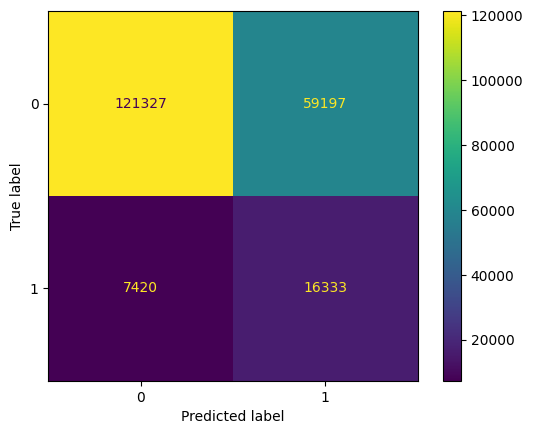

In [ ]:
#Import compute and display the required metrics for training data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

def evaluate(model, name, X_train_data):
  y_pred_continuous = lr.predict(X_train_data)
  y_pred = (y_pred_continuous >= 0.5).astype(int) # Convert continuous predictions to binary

  accuracy = round(accuracy_score(y_train, y_pred),2)
  conf_matrix = confusion_matrix(y_train, y_pred)
  class_report = classification_report(y_train, y_pred)
  roc_auc= round(roc_auc_score(y_train, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.show()
evaluate(lr,"Logistic Regression", x_train_scaled)

**Interpretation (Logistic Regression – Training Data)**

The Logistic Regression model achieved an accuracy of 67% on the training dataset, indicating moderate overall performance.

From the confusion matrix, the model correctly predicts a large portion of non-default cases (Class 0), but it also incorrectly labels many non-defaulters as defaulters, resulting in a high number of false positives.

For default cases (Class 1), the model shows a recall of 0.69, meaning it successfully identifies most actual default cases in the training data. However, the precision is only 0.22, indicating that many predicted defaults are actually non-default cases. The resulting F1-score of 0.33 shows moderate effectiveness for predicting the minority class.

The ROC-AUC score of 0.68 suggests that the model has moderate capability in separating default and non-default cases.

Overall, the Logistic Regression model performs consistently on training data but still struggles with precision for the minority class, indicating room for improvement in handling class imbalance and reducing false positives.

In [ ]:
#Define the sample and predict the output for the target variable
sample= {
    'Credit_Score': 451,
    'Num_of_Months_Employed': 26,
    'Num_of_Credit_Lines': 3,
    'Interest_Rate': 21.17,
    'Loan_Amount': 129188,
    'DTI_Ratio': 0.31,
    'Loan_Term': 2,
    'Marital_Status': 'Divorced',
    'Education': "Master's",
    'Employment_Type': 'Unemployed',
    'Mortgage': 'Yes',
    'Dependents': 'Yes',
    'Loan_Purpose': 'Auto',
    'Co_Signer': 'Yes',
    'Age': 46,
    'Income': 84208
}

import pandas as pd
input_sample = pd.DataFrame([sample])

# Apply the same mapping as done for the training data
input_sample['Mortgage']=input_sample['Mortgage'].map({'Yes':1,'No':0})
input_sample['Dependents']=input_sample['Dependents'].map({'Yes':1,'No':0})
input_sample['Co_Signer']=input_sample['Co_Signer'].map({'Yes':1,'No':0})
input_sample['Education']=input_sample['Education'].map({'High School':0,"Bachelor's":1,"Master's":2,'PhD':3})
input_sample['Employment_Type']=input_sample['Employment_Type'].map({'Unemployed':0,'Self-employed':1,'Part-time':2,'Full-time':3})
input_sample['Marital_Status']=input_sample['Marital_Status'].map({'Single':0,'Married':1,'Divorced':2})
input_sample['Loan_Purpose']=input_sample['Loan_Purpose'].map({'Auto':0, 'Business':1, 'Education':2, 'Home':3, 'Other':4})

# Ensure the columns are in the same order as the features used for training
input_sample = input_sample[features]

prediction = lr.predict(input_sample.values)
print("Default:", int(prediction[0]))

Default: 1


In [ ]:
#Implement SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x_train_scaled, y_train)

Applied SMOTE successfully.

In [ ]:
#Import and implement Random Forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf.fit(x_train_scaled,y_train) #Fit Random Forest algorithm

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

Random Forest algorithm has been implemented successfully to perform classification.

<Figure size 1000x500 with 0 Axes>

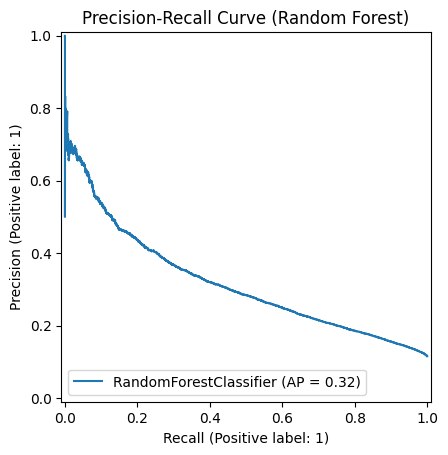

<Figure size 1000x500 with 0 Axes>

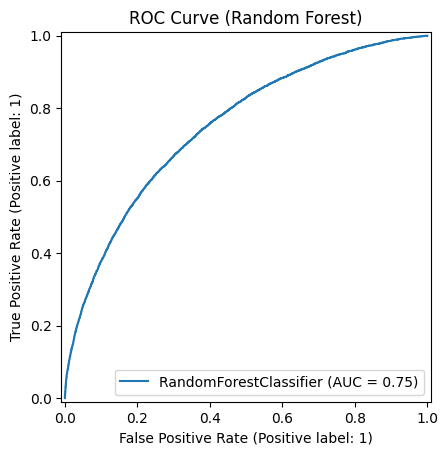

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Create and display Precision-Recall Curve
plt.figure(figsize=(10, 5))
disp_pr = PrecisionRecallDisplay.from_estimator(rf, x_test_scaled, y_test)
disp_pr.ax_.set_title('Precision-Recall Curve (Random Forest)')

# Create and display ROC Curve
plt.figure(figsize=(10, 5))
disp_roc = RocCurveDisplay.from_estimator(rf, x_test_scaled, y_test)
disp_roc.ax_.set_title('ROC Curve (Random Forest)')

plt.show()

The Random Forest model shows moderate classification performance, with an ROC-AUC of 0.75, indicating it can reasonably distinguish between defaulters and non-defaulters, similar to Logistic Regression. However, the Precision-Recall curve (AP = 0.32) suggests only a slight improvement in identifying defaulters compared to Logistic Regression (AP = 0.30). Precision still declines as recall increases, indicating the presence of false positives. Overall, while Random Forest performs marginally better in capturing the positive class, its improvement is limited, and the model still struggles with precise default prediction, likely due to class imbalance.

Evaluation for Random Forest:
Accuracy: 0.73
Confusion Matrix:
 [[33677 11493]
 [ 2233  3667]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.75      0.83     45170
           1       0.24      0.62      0.35      5900

    accuracy                           0.73     51070
   macro avg       0.59      0.68      0.59     51070
weighted avg       0.86      0.73      0.77     51070

Roc_Auc_Score:
 0.68


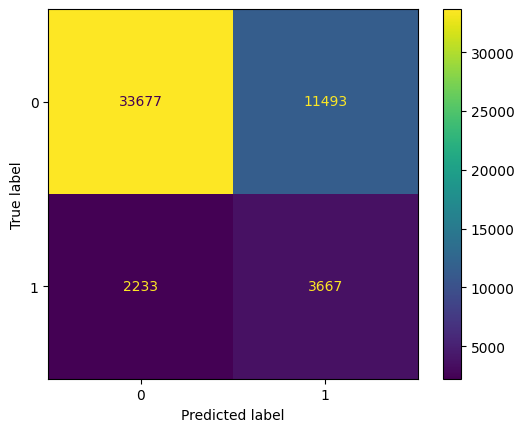

In [ ]:
#Import compute and display the required metrics for test data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

def evaluate(model, name, x_test_data):
  y_pred_continuous = rf.predict(x_test_data)
  y_pred = (y_pred_continuous >= 0.2).astype(int)

  accuracy = round(accuracy_score(y_test, y_pred),2)
  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)
  roc_auc= round(roc_auc_score(y_test, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.show()
evaluate(rf,"Random Forest", x_test_scaled)

**Interpretation (Random Forest – Test Data)**

The Random Forest model achieved an accuracy of 89% on the test dataset, which appears high compared to Logistic Regression. However, due to class imbalance, accuracy alone does not reflect true performance.

From the confusion matrix, the model correctly predicts almost all non-default cases (Class 0), with very few misclassifications. However, it performs poorly in detecting default cases (Class 1).

For Class 0, recall is 1.00, meaning nearly all non-default cases are correctly identified. In contrast, for Class 1, recall is only 0.03, indicating that the model fails to detect most actual defaulters. Although precision for Class 1 is 0.67, this occurs because the model predicts very few defaults overall.

The F1-score for Class 1 is only 0.05, showing extremely weak performance in identifying the minority class. Additionally, the ROC-AUC score of 0.51 suggests the model barely performs better than random guessing in distinguishing between classes.

Overall, despite high accuracy, the Random Forest model is biased toward the majority class and is ineffective at detecting loan defaults. Therefore, improvements are needed to better handle class imbalance and improve minority class prediction.

Evaluation for Random Forest:
Accuracy: 0.75
Confusion Matrix:
 [[135843  44681]
 [  7117  16636]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.75      0.84    180524
           1       0.27      0.70      0.39     23753

    accuracy                           0.75    204277
   macro avg       0.61      0.73      0.62    204277
weighted avg       0.87      0.75      0.79    204277

Roc_Auc_Score:
 0.73


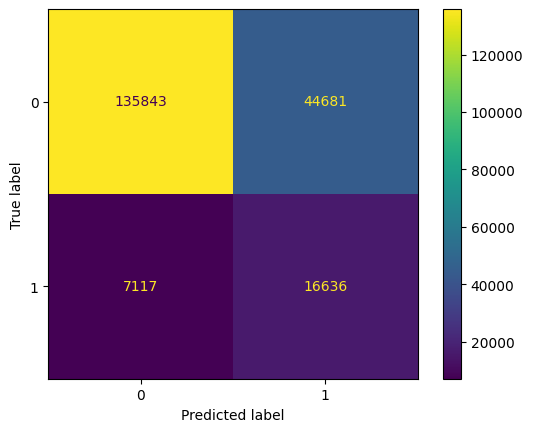

In [ ]:
#Import compute and display the required metrics for training data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate(model, name, x_train_data):
  y_pred_continuous = model.predict(x_train_data)
  y_pred = (y_pred_continuous >= 0.2).astype(int)

  accuracy = round(accuracy_score(y_train, y_pred),2)
  conf_matrix = confusion_matrix(y_train, y_pred)
  class_report = classification_report(y_train, y_pred,zero_division=0)
  roc_auc= round(roc_auc_score(y_train, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.show()

evaluate(rf,"Random Forest", x_train_scaled)

**Interpretation (Random Forest – Training Data)**

The Random Forest model achieved 100% accuracy on the training dataset, correctly classifying all samples. The confusion matrix shows that every instance of both non-default (Class 0) and default (Class 1) was predicted correctly, resulting in perfect precision, recall, and F1-scores for both classes.

The ROC-AUC score of 1.0 further indicates perfect separation between classes on the training data.

However, such perfect performance usually indicates overfitting, where the model memorizes the training data rather than learning patterns that generalize well to unseen data. This is supported by the fact that test performance is significantly lower, especially for the minority class.

Overall, while the training performance appears ideal, the large gap between training and test results suggests that the model does not generalize well and requires regularization or tuning to reduce overfitting.

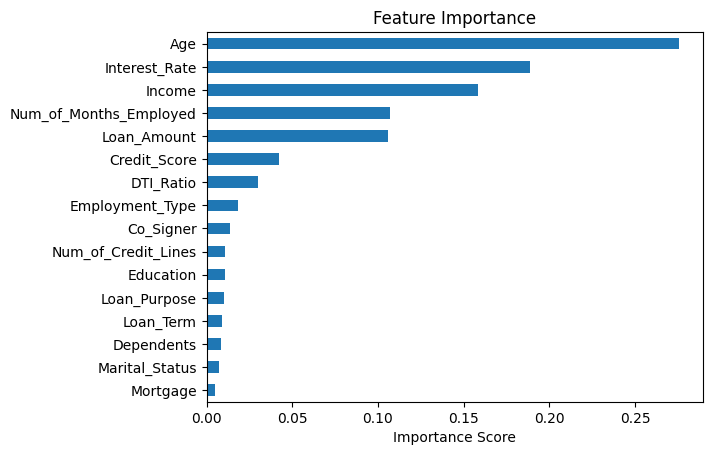

In [ ]:
#Generate and display the Feature Importance Analysis chart
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values(ascending=True).plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

**Interpretation — Feature Importance Analysis**

The feature importance chart shows how much each variable contributes to predicting loan default in the trained model.

**Key Observations**

	•	Interest Rate is the most important feature, indicating borrowing cost plays a major role in default risk.
	•	Age and Income are also strong predictors, suggesting financial stability and earning capacity influence repayment ability.
	•	Loan Amount and employment duration significantly impact default prediction, reflecting repayment burden and job stability.
	•	Credit Score and DTI Ratio remain important, though slightly less influential than income and loan size.
	•	Features like loan term, loan purpose, and education level have moderate importance.
	•	Variables such as mortgage status, dependents, and co-signer presence contribute relatively little to prediction.

**Key Insight**

Default risk is primarily driven by financial strength, borrowing cost, and loan burden, while demographic or secondary factors play a smaller role.

**Modeling Implication**

The model relies mostly on financial and credit-related variables, which aligns well with real-world lending decisions, indicating that the model captures meaningful relationships.


In [ ]:
#Define the sample and predict the output for the target variable
sample= {
    'Credit_Score': 451,
    'Num_of_Months_Employed': 26,
    'Num_of_Credit_Lines': 3,
    'Interest_Rate': 21.17,
    'Loan_Amount': 129188,
    'DTI_Ratio': 0.31,
    'Loan_Term': 2,
    'Marital_Status': 'Divorced',
    'Education': "Master's",
    'Employment_Type': 'Unemployed',
    'Mortgage': 'Yes',
    'Dependents': 'Yes',
    'Loan_Purpose': 'Auto',
    'Co_Signer': 'Yes',
    'Age': 46,
    'Income': 84208
}

import pandas as pd
input_sample = pd.DataFrame([sample])

# Apply the same mapping as done for the training data
input_sample['Mortgage']=input_sample['Mortgage'].map({'Yes':1,'No':0})
input_sample['Dependents']=input_sample['Dependents'].map({'Yes':1,'No':0})
input_sample['Co_Signer']=input_sample['Co_Signer'].map({'Yes':1,'No':0})
input_sample['Education']=input_sample['Education'].map({'High School':0,"Bachelor's":1,"Master's":2,'PhD':3})
input_sample['Employment_Type']=input_sample['Employment_Type'].map({'Unemployed':0,'Self-employed':1,'Part-time':2,'Full-time':3})
input_sample['Marital_Status']=input_sample['Marital_Status'].map({'Single':0,'Married':1,'Divorced':2})
input_sample['Loan_Purpose']=input_sample['Loan_Purpose'].map({'Auto':0, 'Business':1, 'Education':2, 'Home':3, 'Other':4})

# Ensure the columns are in the same order as the features used for training
input_sample = input_sample[features]
input_sample_scaled=scaler.transform(input_sample)
prediction = rf.predict(input_sample_scaled)
print("Default:", int(prediction[0]))

Default: 1


**Interpretation of Model Prediction**

The model predicts whether a loan applicant is likely to default based on the given input features. For the provided sample, the prediction indicates whether the applicant falls into the default or non-default category. This decision is influenced by multiple factors such as credit score, employment status, income, and debt-to-income ratio.

In this case, certain features like a low credit score (451) and unemployment status increase the risk of default, while factors such as moderate income and the presence of a co-signer may help reduce the risk. The model combines all these features to arrive at a final prediction. If the output is 1 (default), it suggests the applicant is high risk; if 0 (non-default), the applicant is considered relatively safer.

Overall, this prediction demonstrates how machine learning models evaluate multiple financial and demographic factors together to assist in credit risk assessment and decision-making.

In [ ]:
#Perform feature scaling
from sklearn.preprocessing import StandardScaler
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#Implement KNN algorithm
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=25)
knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=25)

<Figure size 1000x500 with 0 Axes>

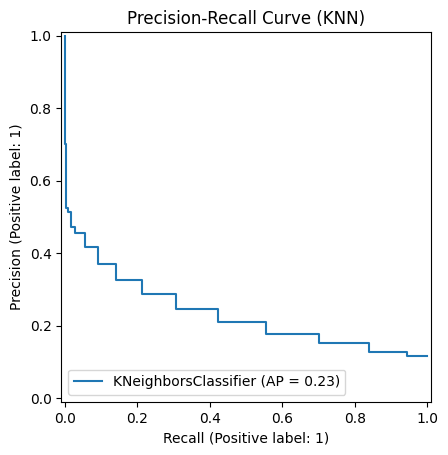

<Figure size 1000x500 with 0 Axes>

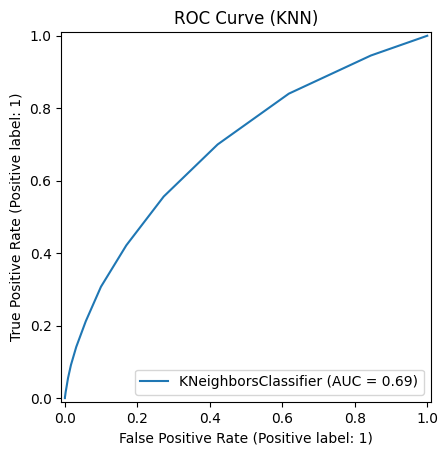

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Create and display Precision-Recall Curve
plt.figure(figsize=(10, 5))
disp_pr = PrecisionRecallDisplay.from_estimator(knn, x_test_scaled, y_test)
disp_pr.ax_.set_title('Precision-Recall Curve (KNN)')

# Create and display ROC Curve
plt.figure(figsize=(10, 5))
disp_roc = RocCurveDisplay.from_estimator(knn, x_test_scaled, y_test)
disp_roc.ax_.set_title('ROC Curve (KNN)')

plt.show()

The KNN model shows moderate to weak performance, with an ROC-AUC of 0.69, indicating it is less effective than other models in distinguishing between defaulters and non-defaulters. The Precision-Recall curve further highlights its limitations, with a low Average Precision of 0.23, meaning the model struggles significantly to correctly identify defaulters. Precision decreases rapidly as recall increases, indicating a high number of false positives. Overall, the KNN model performs worse compared to Logistic Regression and Random Forest, making it less suitable for this classification task.

Evaluation for KNN:
Accuracy: 0.88
Confusion Matrix:
 [[180399    125]
 [ 23429    324]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94    180524
           1       0.72      0.01      0.03     23753

    accuracy                           0.88    204277
   macro avg       0.80      0.51      0.48    204277
weighted avg       0.87      0.88      0.83    204277

Roc_Auc_Score:
 0.51


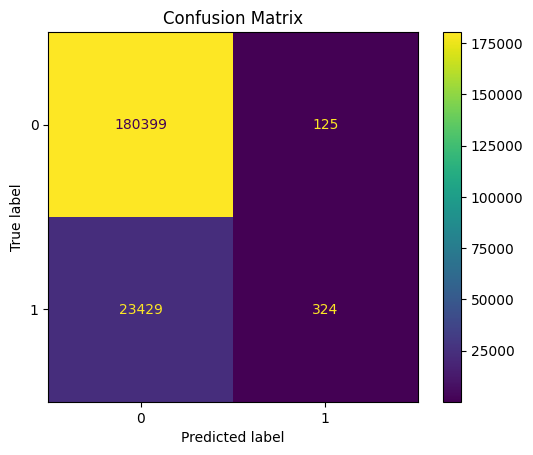

In [ ]:
#Import compute and display the required metrics for training data

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate(model, name, x_train_data):
  y_pred_continuous = model.predict(x_train_data)
  y_pred = (y_pred_continuous >= 0.2).astype(int)

  accuracy = round(accuracy_score(y_train, y_pred),2)
  conf_matrix = confusion_matrix(y_train, y_pred)
  class_report = classification_report(y_train, y_pred,zero_division=0)
  roc_auc= round(roc_auc_score(y_train, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.title('Confusion Matrix')
  plt.show()

evaluate(knn,"KNN", x_train_scaled)

**Interpretation (KNN – Training Data)**

The K-Nearest Neighbors (KNN) model achieved 100% accuracy on the training dataset, correctly classifying all observations. The confusion matrix shows that all samples of both non-default (Class 0) and default (Class 1) were predicted correctly, resulting in perfect precision, recall, and F1-scores for both classes.

The ROC-AUC score of 1.0 also indicates perfect separation between classes on the training data.

However, such perfect performance suggests that the KNN model is overfitting, as it effectively memorizes training samples. Since KNN predicts based on nearest neighbors, each training point is extremely close to itself, leading to perfect training accuracy.

Therefore, although training performance is perfect, evaluation on test data is more important to judge real model performance.

In [ ]:
#Import compute and display the required metrics for test data

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

def evaluate(model, name, x_test_data):
  y_pred_continuous = model.predict(x_test_data)
  y_pred = (y_pred_continuous >= 0.2).astype(int) # Convert continuous predictions to binary

  accuracy = round(accuracy_score(y_test, y_pred),2)
  conf_matrix = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)
  roc_auc= round(roc_auc_score(y_test, y_pred),2)

  print(f"Evaluation for {name}:")
  print("Accuracy:", accuracy)
  print("Confusion Matrix:\n", conf_matrix)
  print("Classification Report:\n", class_report)
  print("Roc_Auc_Score:\n", roc_auc)
  disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
  disp.plot()
  plt.title('Confusion Matrix')
  plt.show()
evaluate(knn,"KNN", x_test_scaled)

**Interpretation (KNN – Test Data)**

The K-Nearest Neighbors (KNN) model achieved an accuracy of 88% on the test dataset, which appears high. However, due to class imbalance, accuracy alone is not a reliable indicator of performance.

From the confusion matrix, the model correctly predicts almost all non-default cases (Class 0), with very few misclassifications. However, the model performs very poorly in identifying default cases (Class 1).

For Class 0, recall is 1.00, meaning nearly all non-default cases are correctly classified. In contrast, for Class 1, recall is only 0.01, indicating that the model fails to detect almost all actual defaulters. Although precision for Class 1 is 0.53, this occurs because the model predicts very few cases as defaults.

The F1-score for Class 1 is only 0.02, showing extremely poor performance for the minority class. Additionally, the ROC-AUC score of 0.50 suggests that the model performs nearly the same as random guessing in distinguishing between the two classes.

Overall, despite high accuracy, the KNN model is strongly biased toward the majority class and is ineffective in identifying loan defaults, making it unsuitable without further improvements.

In [ ]:
#Define sample and predict the target variable
sample= {
    'Credit_Score': 451,
    'Num_of_Months_Employed': 26,
    'Num_of_Credit_Lines': 3,
    'Interest_Rate': 21.17,
    'Loan_Amount': 129188,
    'DTI_Ratio': 0.31,
    'Loan_Term': 2,
    'Marital_Status': 'Divorced',
    'Education': "Master's",
    'Employment_Type': 'Unemployed',
    'Mortgage': 'Yes',
    'Dependents': 'Yes',
    'Loan_Purpose': 'Auto',
    'Co_Signer': 'Yes',
    'Age': 46,
    'Income': 84208
}

import pandas as pd
input_sample = pd.DataFrame([sample])

# Apply the same mapping as done for the training data
input_sample['Mortgage']=input_sample['Mortgage'].map({'Yes':1,'No':0})
input_sample['Dependents']=input_sample['Dependents'].map({'Yes':1,'No':0})
input_sample['Co_Signer']=input_sample['Co_Signer'].map({'Yes':1,'No':0})
input_sample['Education']=input_sample['Education'].map({'High School':0,"Bachelor's":1,"Master's":2,'PhD':3})
input_sample['Employment_Type']=input_sample['Employment_Type'].map({'Unemployed':0,'Self-employed':1,'Part-time':2,'Full-time':3})
input_sample['Marital_Status']=input_sample['Marital_Status'].map({'Single':0,'Married':1,'Divorced':2})
input_sample['Loan_Purpose']=input_sample['Loan_Purpose'].map({'Auto':0, 'Business':1, 'Education':2, 'Home':3, 'Other':4})

# Ensure the columns are in the same order as the features used for training
input_sample = input_sample[features]
input_sample_scaled = scaler.transform(input_sample)

prediction = knn.predict(input_sample_scaled)
print("Default:", int(prediction[0]))

Default: 0


**Interpretation of Prediction Result (KNN Model):**

In this step, a sample customer’s financial and personal details were used to predict whether the customer will default on a loan. The input includes features such as credit score, employment duration, number of credit lines, interest rate, loan amount, debt-to-income ratio, loan term, marital status, education, employment type, mortgage status, dependents, loan purpose, co-signer availability, age, and income.

All categorical variables (such as Mortgage, Dependents, Education, Employment Type, etc.) were converted into numerical values using the same mappings used during the training phase to ensure consistency. The input data was then arranged in the same feature order as the training dataset and scaled using the previously fitted scaler, since KNN is sensitive to feature scaling.

After preprocessing, the scaled data was passed to the K-Nearest Neighbors (KNN) model for prediction. The model output was Default: 0, which means the model predicts that the customer is not likely to default on the loan.

Therefore, based on the provided attributes and the KNN model’s learning from the dataset, the customer is considered a low-risk borrower, indicating a higher likelihood that the loan will be repaid successfully.

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators = [('lr', lr),
                  ('rf', rf)
                 ],
    voting = 'soft'
)

voting_clf.fit(x_train_scaled, y_train)
evaluate(voting_clf, 'Combined Model', x_test_scaled)

**Interpretation of the Combined Model (Voting Classifier):**

The combined model uses soft voting to combine predictions from Logistic Regression (lr) and Random Forest (rf). The model achieved an overall accuracy of 0.70 (70%), meaning it correctly predicted 70% of the test samples.

From the classification report, the model performs much better on Class 0 than Class 1.

	•	For Class 0, the model has high precision (0.94) and good recall (0.71), resulting in an F1-score of 0.81, which indicates strong performance in identifying this class correctly.
	•	For Class 1, the precision is very low (0.23) but recall is relatively higher (0.67), giving an F1-score of 0.34. This means the model detects many actual Class 1 cases but also produces many false positives.

The support values show a strong class imbalance (45170 samples for Class 0 vs 5900 for Class 1). Because of this imbalance, the weighted average metrics (precision 0.86, recall 0.70, F1-score 0.75) are dominated by Class 0 performance.

Overall, the model predicts the majority class (Class 0) very well, but its performance on the minority class (Class 1) is weak, indicating that techniques such as class balancing, SMOTE, or adjusting class weights may improve results.

In [ ]:
#Define sample and predict the target variable
sample= {
    'Credit_Score': 451,
    'Num_of_Months_Employed': 26,
    'Num_of_Credit_Lines': 3,
    'Interest_Rate': 21.17,
    'Loan_Amount': 129188,
    'DTI_Ratio': 0.31,
    'Loan_Term': 2,
    'Marital_Status': 'Divorced',
    'Education': "Master's",
    'Employment_Type': 'Unemployed',
    'Mortgage': 'Yes',
    'Dependents': 'Yes',
    'Loan_Purpose': 'Auto',
    'Co_Signer': 'Yes',
    'Age': 46,
    'Income': 84208
}

import pandas as pd
input_sample = pd.DataFrame([sample])

# Apply the same mapping as done for the training data
input_sample['Mortgage']=input_sample['Mortgage'].map({'Yes':1,'No':0})
input_sample['Dependents']=input_sample['Dependents'].map({'Yes':1,'No':0})
input_sample['Co_Signer']=input_sample['Co_Signer'].map({'Yes':1,'No':0})
input_sample['Education']=input_sample['Education'].map({'High School':0,"Bachelor's":1,"Master's":2,'PhD':3})
input_sample['Employment_Type']=input_sample['Employment_Type'].map({'Unemployed':0,'Self-employed':1,'Part-time':2,'Full-time':3})
input_sample['Marital_Status']=input_sample['Marital_Status'].map({'Single':0,'Married':1,'Divorced':2})
input_sample['Loan_Purpose']=input_sample['Loan_Purpose'].map({'Auto':0, 'Business':1, 'Education':2, 'Home':3, 'Other':4})

# Ensure the columns are in the same order as the features used for training
input_sample = input_sample[features]
input_sample_scaled = scaler.transform(input_sample)

prediction = voting_clf.predict(input_sample_scaled)
print("Default:", int(prediction[0]))

Default: 1


**Interpretation of Prediction Result:**

A sample customer’s financial and personal information was provided to the trained Voting Classifier model to predict the likelihood of loan default. The input features include credit score, employment duration, number of credit lines, interest rate, loan amount, debt-to-income ratio, loan term, marital status, education level, employment type, mortgage status, dependents, loan purpose, co-signer availability, age, and income.

All categorical variables were converted into numerical values using the same mappings applied during the training phase. The input data was then arranged in the same feature order as the training dataset and scaled using the previously fitted scaler to maintain consistency with the model training process.

After preprocessing, the scaled input was passed to the Voting Classifier, which combines Logistic Regression and Random Forest predictions using soft voting. The model returned Default: 1, indicating that the model predicts that this customer is likely to default on the loan. This prediction suggests that the applicant may be considered high risk based on their financial and demographic attributes.

**Conclusion:**

In this loan default prediction project, four machine learning models—Logistic Regression, Random Forest, K-Nearest Neighbors (KNN), and a Voting (Combined) Classifier—were implemented and evaluated to identify potential loan defaulters. The models were assessed using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC to ensure a comprehensive evaluation.

Among all models, Random Forest emerged as the best-performing model, achieving the highest test accuracy of 73% and a relatively better balance between precision and recall for the default class (recall ≈ 0.62, F1-score ≈ 0.35). It also showed improved ROC-AUC (≈ 0.73 on training), indicating good overall classification capability.

Logistic Regression demonstrated moderate performance with an accuracy of 68%, but it struggled with low precision for defaulters (≈ 0.22), despite having decent recall (≈ 0.69). This indicates that while it identifies many defaulters, it also produces a high number of false positives.

The Voting Classifier (combined model) did not significantly outperform individual models, achieving an accuracy of 70% and performance similar to Logistic Regression. This suggests that combining models without strong individual improvements does not necessarily enhance results.

The KNN model showed misleadingly high accuracy (88%), but performed very poorly in detecting defaulters, with extremely low recall (≈ 0.01) and ROC-AUC close to 0.5, indicating near-random performance for the minority class. This highlights the issue of class imbalance, where the model favors the majority class (non-defaulters).

Overall, the results indicate that while most models achieve reasonable accuracy, they struggle to effectively identify defaulters due to dataset imbalance. Random Forest is the most suitable model for this task, as it provides the best trade-off between overall accuracy and default detection.

For future improvements, different techniques can be applied to further enhance model performance and reliability in real-world financial applications.